# Poll weighting: controlled historical and current experiments

We test seven weighting rules using the same screened Senate samples, candidate mappings and LV/RV selection. The final Gaussian remains the reference; this notebook does not change production/live models or download data. Run notebook04 first if you want a newer source snapshot.

The experiment changes polling **means**. Priors, state relationships, historical polling variance budgets and evidence-mass precision stay fixed. We compare frozen historical bias with bias re-estimated from earlier cycles under each rule. This isolates weighting; it is **not** a full retuning of every model under a new likelihood. Only the main Gaussian is tested here.

See [full design and assumptions](../docs/POLL_WEIGHT_EXPERIMENT.md).

In [2]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),Path.cwd().parent] if (p/'election_lab.py').exists())
sys.path.insert(0,str(ROOT))
import election_lab as lab
import poll_weight_experiment as experiment
pd.set_option('display.max_rows',50)
FORCE=False
FIRST_CYCLE=2016
CALIBRATION='Refit bias'  # Also compare "Frozen bias" below.
RUN=lab.run_logged(experiment.run,force=FORCE)
meta=json.loads((RUN/'run.json').read_text())
tables={name:pd.read_parquet(RUN/(name+'.parquet')) for name in ['summary','cycle_scores','predictions','seats','raw_summary','ratings','sample_weights','checks']}
print('Saved run:',RUN.relative_to(ROOT),'| Current cutoff:',meta['as_of'])
print('Live source:',meta['source_live'],'| Stale sources:',meta['freshness'].get('stale_sources'))


Run log: cache/logs/run_20260921T044728.424683Z.txt
Saved run: cache/runs/poll_weights/20260921T044728.506084Z | Current cutoff: 2026-09-21
Live source: cache/runs/live/20260921T044340.518203Z | Stale sources: ['fred']


## 1. Weighting rules and missing information

| Variant | Weight before normalization within contest |
|---|---|
| Firm balanced (reference) | 30-day decay / samples from that firm |
| Equal polls, 30d | 30-day decay |
| Respondent n, 30d | 30-day decay × reported participants |
| Firm balanced + within-firm n | 30-day decay × n / sum of n within firm |
| Firm + rating mild / strong | Reference × preceding-cycle rating multiplier |
| Equal polls, no decay | Exactly one per screened sample |

“Poll” here means one screened underlying sample, not each candidate/question row. Missing/nonpositive n uses the median positive n from earlier cycles at this horizon, or 1,000 if none. These imputations affect only n-weighted variants and are logged. Respondent weights are intentionally uncapped in this first test.

Ratings default to1. We compare firms' last-cycle absolute errors against the median firm error **in the same contest**, using samples from the last30 days before the same forecast horizon. Each firm/contest contributes once; races with only one firm provide no comparative rating. Shrinkage toward1 and caps[0.5,2] limit tiny-history effects. Nothing from the forecast cycle's results is used.

In [3]:
weights=tables['sample_weights']
current=weights[weights.evidence.eq('live')]
info=current[current.variant.eq('Respondent n, 30d')]
print('Current samples:',len(info),'| Missing/invalid n filled:',int(info.imputed_n.sum()))
factors=current[current.variant.eq('Firm + last-cycle rating strong')].groupby('firm').agg(multiplier=('rating_multiplier','first'),samples=('sample_key','nunique')).reset_index()
ratings=tables['ratings'].query('evidence == "live"')
display(factors.merge(ratings[['firm','contests','excess_mae_pp','reliability','source_cycle']],on='firm',how='left').sort_values('multiplier',ascending=False).round(3))
print('Missing rating history means neutral multiplier1; those fields remain NaN.')


Current samples: 233 | Missing/invalid n filled: 0


,firm,multiplier,samples,contests,excess_mae_pp,reliability,source_cycle
70,wick,1.339,1,1.0,-3.500,0.250,2024.0
16,emerson college,1.301,15,11.0,-1.005,0.786,2024.0
54,surveyusa,1.284,1,1.0,-3.000,0.250,2024.0
9,cnn/ssrs,1.260,2,4.0,-1.214,0.571,2024.0
17,epic-mra,1.201,2,1.0,-2.200,0.250,2024.0
...,...,...,...,...,...,...,...
49,socal strategies,0.874,3,2.0,1.010,0.400,2024.0
8,change research,0.763,8,1.0,3.250,0.250,2024.0
73,yougov,0.755,11,3.0,1.683,0.500,2024.0
60,tipp insights,0.729,4,1.0,3.800,0.250,2024.0


Missing rating history means neutral multiplier1; those fields remain NaN.


## 2. Historical main-model scores

Recent2016–2024: five cycles,140 modeled contests per horizon. `matched_live` uses the frozen September17 research cutoff; `oct31` uses October31. MAE/Brier/WIS average cycle means; accuracy/coverage pool contests. Lower MAE/Brier/WIS is better. `correct/n` counts winners, not seats predicted exactly.

Every calibration uses earlier-cycle labels. Architecture experiments reused these evaluation years, so these are exploratory chronological comparisons. The two calibration arms show whether using the original error correction with new weights obscures the effect.

,scenario,variant,calibration,correct,n,absolute_error_pp,brier,coverage70,width70_pp
28,matched_live,"Equal polls, 30d",Frozen bias,127,140,6.3317,0.0567,77.8571,19.8764
29,matched_live,"Equal polls, 30d",Refit bias,128,140,6.3302,0.0567,77.8571,19.8764
30,matched_live,"Equal polls, no decay",Frozen bias,126,140,6.1219,0.0570,79.2857,19.8764
31,matched_live,"Equal polls, no decay",Refit bias,126,140,6.1165,0.0571,79.2857,19.8764
32,matched_live,Firm + last-cycle rating mild,Frozen bias,128,140,6.3011,0.0553,78.5714,19.8764
33,matched_live,Firm + last-cycle rating mild,Refit bias,128,140,6.2998,0.0553,78.5714,19.8764
34,matched_live,Firm + last-cycle rating strong,Frozen bias,128,140,6.2984,0.0553,77.8571,19.8764
35,matched_live,Firm + last-cycle rating strong,Refit bias,128,140,6.2962,0.0553,77.8571,19.8764
36,matched_live,Firm balanced (reference),Frozen bias,128,140,6.3067,0.0555,78.5714,19.8764
37,matched_live,Firm balanced (reference),Refit bias,128,140,6.3067,0.0555,78.5714,19.8764


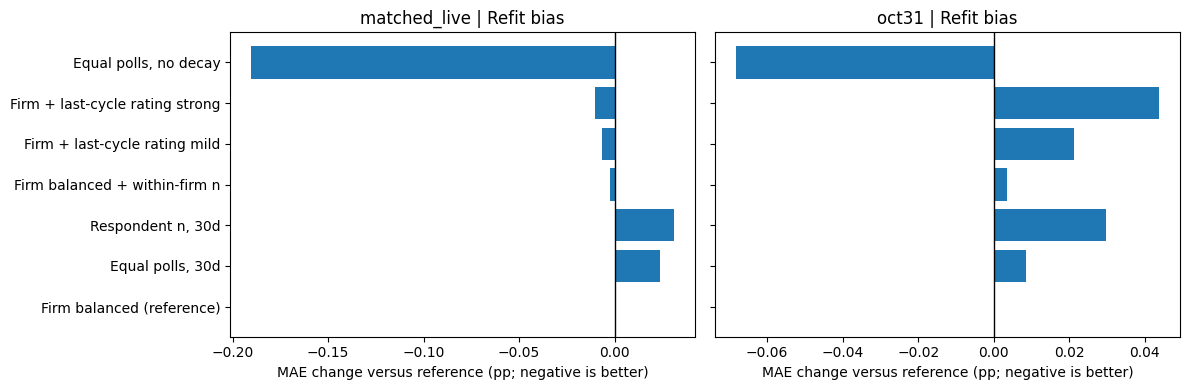

In [4]:
summary=tables['summary'];recent=summary[summary.first_cycle.eq(FIRST_CYCLE)]
display(recent[['scenario','variant','calibration','correct','n','absolute_error_pp','brier','coverage70','width70_pp']].round(4))
chosen=recent[recent.calibration.eq(CALIBRATION)]
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,(sc,g) in zip(axes,chosen.groupby('scenario')):
    baseline=float(g.loc[g.variant.eq(experiment.REFERENCE),'absolute_error_pp'].iloc[0])
    g=g.set_index('variant').reindex(experiment.RULES)
    ax.barh(g.index,g.absolute_error_pp-baseline)
    ax.axvline(0,color='black',lw=1);ax.set(title=sc+' | '+CALIBRATION,xlabel='MAE change versus reference (pp; negative is better)')
axes[1].set_yticklabels([]);fig.tight_layout();plt.show()


## 3. Cycle-by-cycle and raw polling comparison

The first tables expose individual cycles, including older2012/2014 folds. Raw polling is evaluated only where there is a poll:102 September and125 October cases during2016–2024. Its MAE below pools those cases; it should not be directly compared with the140-case, equal-cycle-weighted Gaussian MAE above. No-poll states have no fabricated raw prediction.

In [5]:
cycle=tables['cycle_scores'].query('calibration == @CALIBRATION')
print('Main Gaussian MAE (pp), each cycle')
display(cycle.pivot(index=['scenario','cycle'],columns='variant',values='absolute_error_pp').reindex(columns=experiment.RULES).round(3))
print('Correct calls, each cycle')
display(cycle.pivot(index=['scenario','cycle'],columns='variant',values='correct').reindex(columns=experiment.RULES))
print('Raw polls only: recent2016–2024, pooled observed races')
display(tables['raw_summary'].round(3))


Main Gaussian MAE (pp), each cycle


variant             Firm balanced (reference)  Equal polls, 30d  \
scenario     cycle                                                
matched_live 2012                       7.486             7.483   
             2014                      10.222            10.213   
             2016                       7.846             7.846   
             2018                       3.761             3.700   
             2020                       7.847             8.040   
             2022                       7.391             7.384   
             2024                       4.688             4.681   
oct31        2012                       5.400             5.362   
             2014                       5.545             5.478   
             2016                       6.629             6.575   
             2018                       3.442             3.418   
             2020                       6.345             6.329   
             2022                       5.327             5.400   
             2024                       4.287             4.351   

variant             Respondent n, 30d  Firm balanced + within-firm n  \
scenario     cycle                                                     
matched_live 2012               7.608                          7.486   
             2014              10.273                         10.220   
             2016               7.849                          7.846   
             2018               3.784                          3.752   
             2020               8.092                          7.842   
             2022               7.377                          7.397   
             2024               4.587                          4.684   
oct31        2012               5.360                          5.407   
             2014               5.413                          5.557   
             2016               6.621                          6.626   
             2018               3.541                          3.442   
             2020               6.359                          6.354   
             2022               5.306                          5.337   
             2024               4.352                          4.288   

variant             Firm + last-cycle rating mild  \
scenario     cycle                                  
matched_live 2012                           7.485   
             2014                          10.252   
             2016                           7.862   
             2018                           3.744   
             2020                           7.824   
             2022                           7.386   
             2024                           4.683   
oct31        2012                           5.389   
             2014                           5.565   
             2016                           6.642   
             2018                           3.484   
             2020                           6.344   
             2022                           5.377   
             2024                           4.289   

variant             Firm + last-cycle rating strong  Equal polls, no decay  
scenario     cycle                                                          
matched_live 2012                             7.483                  7.482  
             2014                            10.258                 10.198  
             2016                             7.882                  7.844  
             2018                             3.732                  3.556  
             2020                             7.811                  8.022  
             2022                             7.380                  6.793  
             2024                             4.677                  4.367  
oct31        2012                             5.379                  5.611  
             2014                             5.594                  5.685  
             2016                             6.656                  6.604  
 

Correct calls, each cycle


variant             Firm balanced (reference)  Equal polls, 30d  \
scenario     cycle                                                
matched_live 2012                        29.0              29.0   
             2014                        23.0              23.0   
             2016                        23.0              23.0   
             2018                        28.0              28.0   
             2020                        25.0              25.0   
             2022                        25.0              25.0   
             2024                        27.0              27.0   
oct31        2012                        30.0              30.0   
             2014                        26.0              26.0   
             2016                        24.0              25.0   
             2018                        30.0              28.0   
             2020                        25.0              25.0   
             2022                        26.0              26.0   
             2024                        27.0              27.0   

variant             Respondent n, 30d  Firm balanced + within-firm n  \
scenario     cycle                                                     
matched_live 2012                28.0                           29.0   
             2014                23.0                           23.0   
             2016                23.0                           23.0   
             2018                28.0                           28.0   
             2020                25.0                           25.0   
             2022                25.0                           25.0   
             2024                27.0                           27.0   
oct31        2012                30.0                           30.0   
             2014                25.0                           26.0   
             2016                25.0                           24.0   
             2018                28.0                           30.0   
             2020                25.0                           25.0   
             2022                26.0                           26.0   
             2024                27.0                           27.0   

variant             Firm + last-cycle rating mild  \
scenario     cycle                                  
matched_live 2012                            29.0   
             2014                            23.0   
             2016                            23.0   
             2018                            28.0   
             2020                            25.0   
             2022                            25.0   
             2024                            27.0   
oct31        2012                            30.0   
             2014                            26.0   
             2016                            24.0   
             2018                            30.0   
             2020                            25.0   
             2022                            26.0   
             2024                            27.0   

variant             Firm + last-cycle rating strong  Equal polls, no decay  
scenario     cycle                                                          
matched_live 2012                              29.0                   29.0  
             2014                              23.0                   23.0  
             2016                              23.0                   23.0  
             2018                              28.0                   28.0  
             2020                              25.0                   24.0  
             2022                              25.0                   25.0  
             2024                              27.0                   26.0  
oct31        2012                              30.0                   30.0  
             2014                              26.0                   26.0  
             2016                              24.0                   24.0  
 

Raw polls only: recent2016–2024, pooled observed races


,scenario,variant,n,mae_pp,correct
0,matched_live,"Equal polls, 30d",102,6.113,92.0
1,matched_live,"Equal polls, no decay",102,5.807,90.0
2,matched_live,Firm + last-cycle rating mild,102,6.162,90.0
3,matched_live,Firm + last-cycle rating strong,102,6.164,90.0
4,matched_live,Firm balanced (reference),102,6.163,90.0
5,matched_live,Firm balanced + within-firm n,102,6.168,90.0
6,matched_live,"Respondent n, 30d",102,6.159,92.0
7,oct31,"Equal polls, 30d",125,5.634,115.0
8,oct31,"Equal polls, no decay",125,5.655,114.0
9,oct31,Firm + last-cycle rating mild,125,5.680,112.0


## 4. Current chamber and state forecasts

All variants use the same saved current data. Expected seats sum probabilities; point seats count positive mean margins. D control requires51 seats, with continuing seats included. A tiny change near zero can flip a point call while barely changing the expected seat count.

Only polling means and optionally historical bias estimates change. The entire Gaussian posterior margin covariance is verified unchanged. Seat probabilities can still change when those means cross winner thresholds.

In [6]:
seats=tables['seats'];live_seats=seats[seats.evidence.eq('live')].copy()
live_seats['D control %']=100*live_seats.p_D_control
display(live_seats[['variant','calibration','point_D','point_R','expected_D','D control %','D_lo70','D_hi70']].round(3))
live=tables['predictions'].query('evidence == "live" and calibration == @CALIBRATION')
print('D−R predicted margins (pp)')
display(live.pivot(index=['geography','special'],columns='variant',values='margin_pp').reindex(columns=experiment.RULES).round(2))
print('Democratic win probabilities (%)')
display((100*live.pivot(index=['geography','special'],columns='variant',values='p_dem')).reindex(columns=experiment.RULES).round(1))
print('Raw poll margins (pp; missing means no admitted poll)')
display(live.pivot(index=['geography','special'],columns='variant',values='q_pp').reindex(columns=experiment.RULES).round(2))


,variant,calibration,point_D,point_R,expected_D,D control %,D_lo70,D_hi70
210,Firm balanced (reference),Frozen bias,51,49,50.320,45.520,49,52
211,Firm balanced (reference),Refit bias,51,49,50.320,45.520,49,52
212,"Equal polls, 30d",Frozen bias,51,49,50.363,46.590,49,52
213,"Equal polls, 30d",Refit bias,51,49,50.363,46.547,49,52
214,"Respondent n, 30d",Frozen bias,51,49,50.396,47.460,49,52
215,"Respondent n, 30d",Refit bias,51,49,50.390,47.313,49,52
216,Firm balanced + within-firm n,Frozen bias,51,49,50.309,45.227,49,52
217,Firm balanced + within-firm n,Refit bias,51,49,50.308,45.217,49,52
218,Firm + last-cycle rating mild,Frozen bias,51,49,50.305,45.040,49,52
219,Firm + last-cycle rating mild,Refit bias,51,49,50.304,45.040,49,52


D−R predicted margins (pp)


,variant,Firm balanced (reference),"Equal polls, 30d","Respondent n, 30d",Firm balanced + within-firm n,Firm + last-cycle rating mild,Firm + last-cycle rating strong,"Equal polls, no decay"
geography,special,,,,,,,
AK,False,-3.10,-2.90,-2.93,-3.12,-3.12,-3.15,-3.20
AL,False,-22.02,-22.00,-21.96,-22.03,-22.02,-22.03,-22.19
AR,False,-20.80,-20.78,-20.39,-20.81,-20.81,-20.82,-21.77
CO,False,17.44,17.45,17.50,17.42,17.43,17.42,17.25
DE,False,24.95,24.97,25.01,24.94,24.94,24.93,24.76
FL,True,-5.48,-5.57,-5.34,-5.49,-5.54,-5.60,-7.37
GA,False,5.22,4.93,5.10,5.20,5.19,5.17,4.55
IA,False,-3.27,-3.30,-3.11,-3.29,-3.36,-3.45,-3.49
ID,False,-25.97,-25.95,-25.89,-25.99,-25.98,-25.99,-26.20


Democratic win probabilities (%)


,variant,Firm balanced (reference),"Equal polls, 30d","Respondent n, 30d",Firm balanced + within-firm n,Firm + last-cycle rating mild,Firm + last-cycle rating strong,"Equal polls, no decay"
geography,special,,,,,,,
AK,False,30.0,31.2,31.0,29.8,29.8,29.7,29.4
AL,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AR,False,0.2,0.2,0.2,0.2,0.2,0.2,0.1
CO,False,92.7,92.8,92.8,92.7,92.7,92.7,92.5
DE,False,99.9,99.9,99.9,99.9,99.9,99.9,99.9
FL,True,20.3,19.9,20.9,20.2,20.0,19.7,13.2
GA,False,80.8,79.5,80.3,80.8,80.7,80.6,77.7
IA,False,29.2,29.0,30.1,29.0,28.6,28.1,27.9
ID,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Raw poll margins (pp; missing means no admitted poll)


,variant,Firm balanced (reference),"Equal polls, 30d","Respondent n, 30d",Firm balanced + within-firm n,Firm + last-cycle rating mild,Firm + last-cycle rating strong,"Equal polls, no decay"
geography,special,,,,,,,
AK,False,1.21,1.61,1.49,1.16,1.16,1.11,1.18
AL,False,-15.00,-15.00,-15.00,-15.00,-15.00,-15.00,-15.00
AR,False,-6.12,-6.12,-4.72,-6.12,-6.12,-6.12,-9.40
CO,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DE,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FL,True,-2.91,-3.14,-2.64,-2.92,-3.03,-3.14,-6.89
GA,False,6.78,6.14,6.47,6.76,6.74,6.70,5.57
IA,False,-0.51,-0.50,-0.18,-0.55,-0.66,-0.80,-0.54
ID,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Audit and interpretation

No current-year outcome is used. Reference aggregation and both reference calibration arms must reproduce the existing Gaussian. Reported n is retained alongside the effective weighting n. Unranked firms remain included at weight1. The no-decay case intentionally changes both aggregation and timing and should be read separately.

This experiment does not establish that larger polls have no value or that all pollsters are equally reliable. It tests specific averaging rules with our existing calibration. A change to confidence/variance, LV/RV corrections or pollster-specific likelihoods would be a separate experiment. No rule is promoted automatically.

In [7]:
checks=tables['checks'];assert checks.covariance_preserved.all()
assert checks.training_max_cycle.lt(checks.cycle).all()
p=tables['predictions'];assert p[p.cycle.eq(2026)].actual.isna().all()
assert tables['ratings'].source_cycle.lt(tables['ratings'].cycle).all()
lab.verify_run(RUN)
print(len(checks),'case/variant/calibration checks passed; reference reproduced and run manifest verified.')
print('Detailed sample weights, ratings, bias estimates and all cycle results are saved under',RUN.relative_to(ROOT))


224 case/variant/calibration checks passed; reference reproduced and run manifest verified.
Detailed sample weights, ratings, bias estimates and all cycle results are saved under cache/runs/poll_weights/20260921T044728.506084Z


## Saved reports

[Read the published report](../outputs/reports/experiments/poll_weights.md) · [All outputs and dated reports](../outputs/README.md)
